In [25]:
import numpy as np
from scipy import stats
import pandas as pd 
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns

metric_df = pd.read_csv("/Users/ychen4/Documents/Codebase/automatic-metrics/en-metric-may2026.csv")
metric_columns = list(metric_df.columns)
print(metric_columns)
data_df = pd.read_csv("/Users/ychen4/Documents/Codebase/automatic-metrics/data/mimic-hallu-may29.csv")
data_df.columns



['self_bleu', 'mover_score', 'WMD', 'sms', 'weem4ts', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1', 'sent_bert', 'rouge1_f1', 'rouge2_f1', 'rougeL_f1', 'rouge-w-1.2', 'rouge-s4', 'rouge-su4', 'meteor', 'perplexity', 'js_divergence', 'coverage', 'density', 'compression', 'semantic_coherence', 'redundancy_r1', 'redundancy_r2', 'redundancy_rL', 'abstractivity', 'abstraction_1gram', 'abstraction_2gram', 'uniformity', 'mtld', 'readability', 'sari', 'distinct_1', 'distinct_2', 'distinct_3', 'nist_1', 'bleu_1', 'bleu_1gram_precision_1', 'bleu_2gram_precision_1', 'bleu_3gram_precision_1', 'bleu_4gram_precision_1', 'chrf+_1', 'chrf++_1']


Index(['Unnamed: 0', 'patient_file', 'generation', 'labels', 'model',
       'human_reference', 'hallu_count', 'generation_token', 'reference_token',
       'source_token'],
      dtype='object')

In [26]:
target_columns_all = ['hallu_count']

## Correlation
- Spearman correlation
- Kendall’s tau

In [27]:
# FOR ALL ERRORS 

combined_df_all = pd.concat([metric_df[metric_columns], data_df[target_columns_all]], axis=1).dropna()

# Dictionary to store results
results = {
    'metric': [],
    'target': [],
    'method': [],
    'correlation': [],
    'p_value': [],
    'annot': []
}

# Function to compute correlation and p-value
def compute_corr(method_func, x, y):
    corr, p = method_func(x, y)
    return corr, p


for metric in metric_columns:
    for target in target_columns_all: 
        for method_name, method_func in {
            "pearson r": pearsonr,
            "spearman r": spearmanr,
            "kendall's tau": kendalltau
        }.items():
            corr, p = compute_corr(method_func, combined_df_all[metric], combined_df_all[target])
            results['metric'].append(metric)
            results['target'].append(target)
            results['method'].append(method_name)
            results['correlation'].append(corr)
            results['p_value'].append(p)

            # Significance stars
            if p < 0.001:
                star = '***'
            elif p < 0.01:
                star = '**'
            elif p < 0.05:
                star = '*'
            else:
                star = ''
            results['annot'].append(f"{corr:.3f}{star}")
            
corr_df_all = pd.DataFrame(results)
# corr_df.to_pickle("./output/correlation_dataframe.pkl")

## Kendall's tau correlation

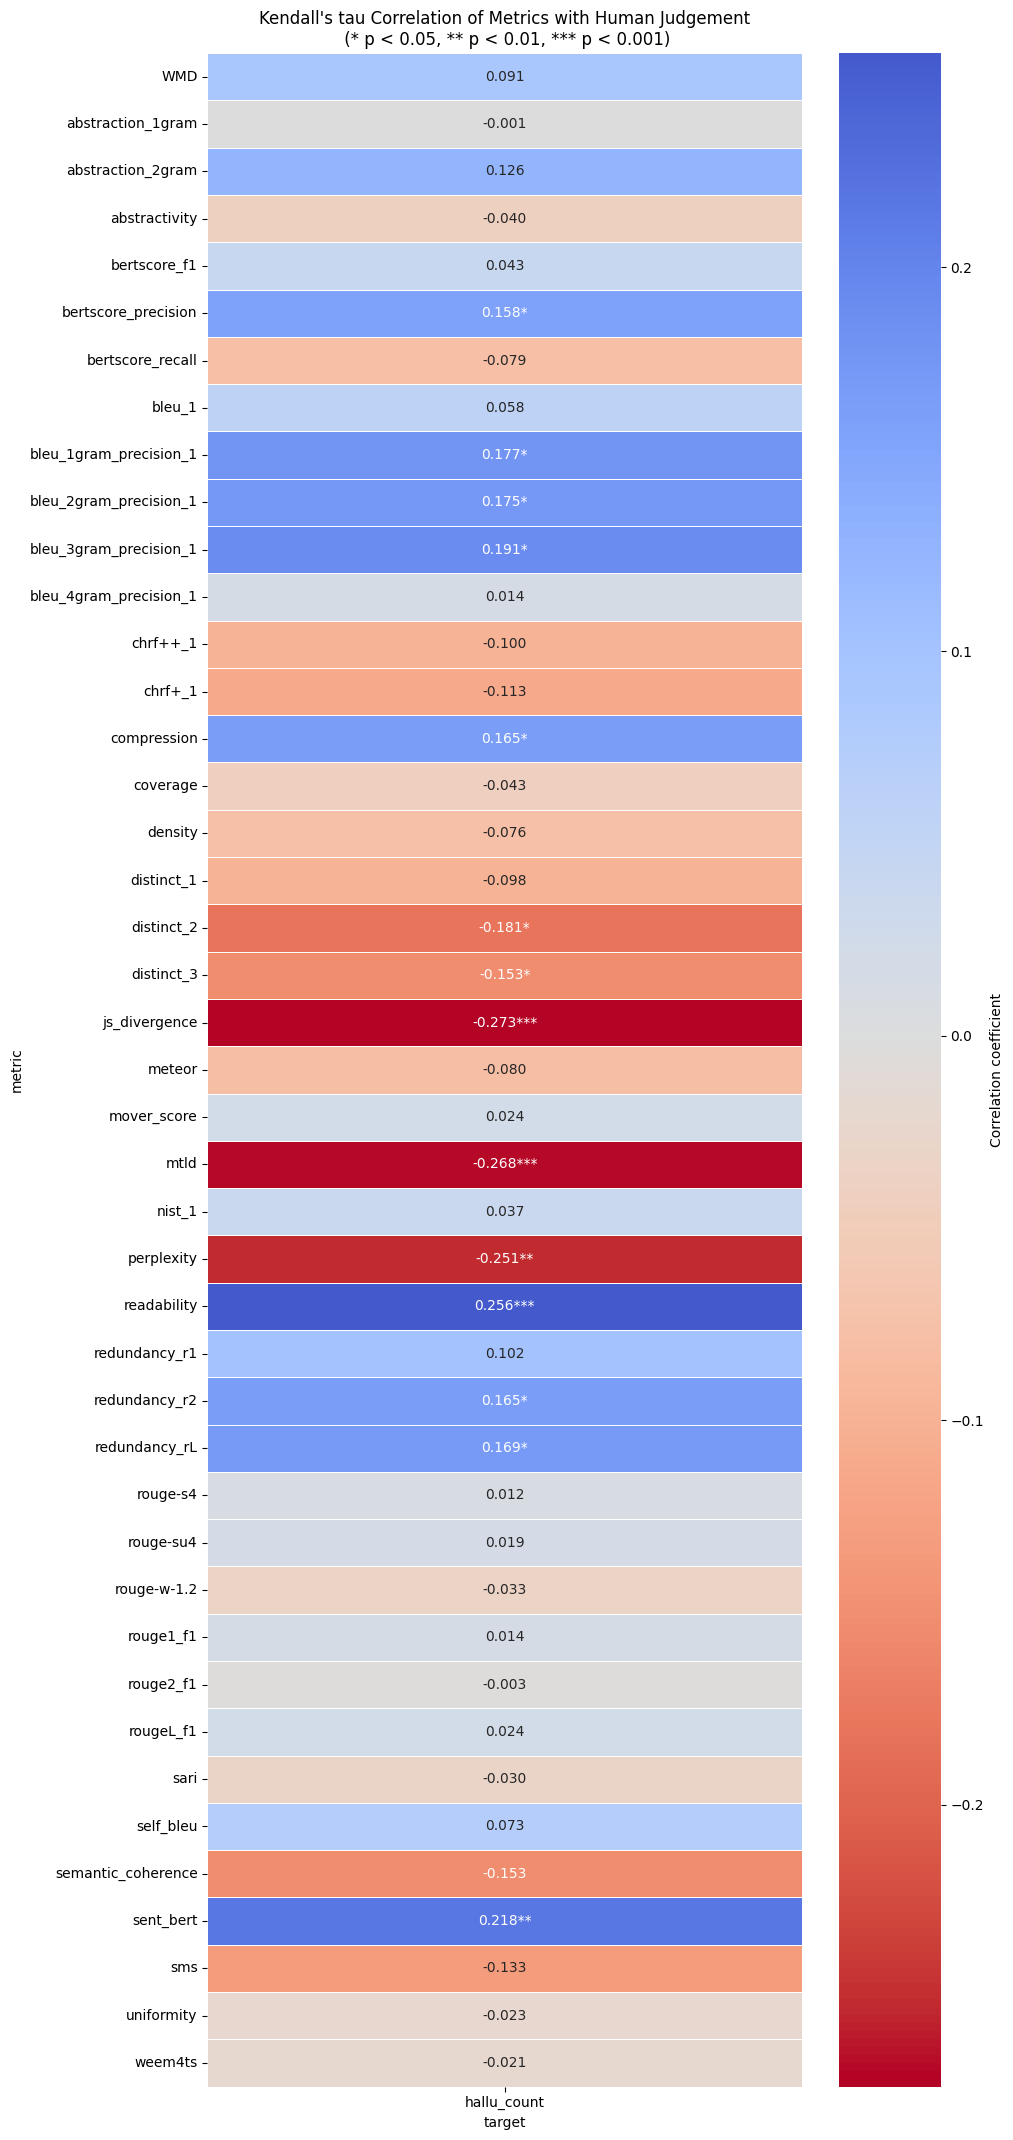

In [28]:
# kendall's tau heatmap
kendall_heatmap_data = corr_df_all[corr_df_all['method'] == "kendall's tau"].pivot(index='metric', columns='target', values='correlation')
kendall_annot_data = corr_df_all[corr_df_all['method'] == "kendall's tau"].pivot(index='metric', columns='target', values='annot')

# Plot
plt.figure(figsize=(10, len(metric_columns) * 0.5 ))
sns.heatmap(
    kendall_heatmap_data,
    annot=kendall_annot_data,
    fmt='',
    cmap='coolwarm_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation coefficient'}
)
plt.title("Kendall's tau Correlation of Metrics with Human Judgement\n (* p < 0.05, ** p < 0.01, *** p < 0.001)")
plt.tight_layout()
plt.show()

In [ ]:
# EXPORT TO EXCEL 
export_table = kendall_annot_data.astype(str)

# Export to Excel
export_table.to_excel("en_kendall_tau_table.xlsx")

## Kendall's tau by group

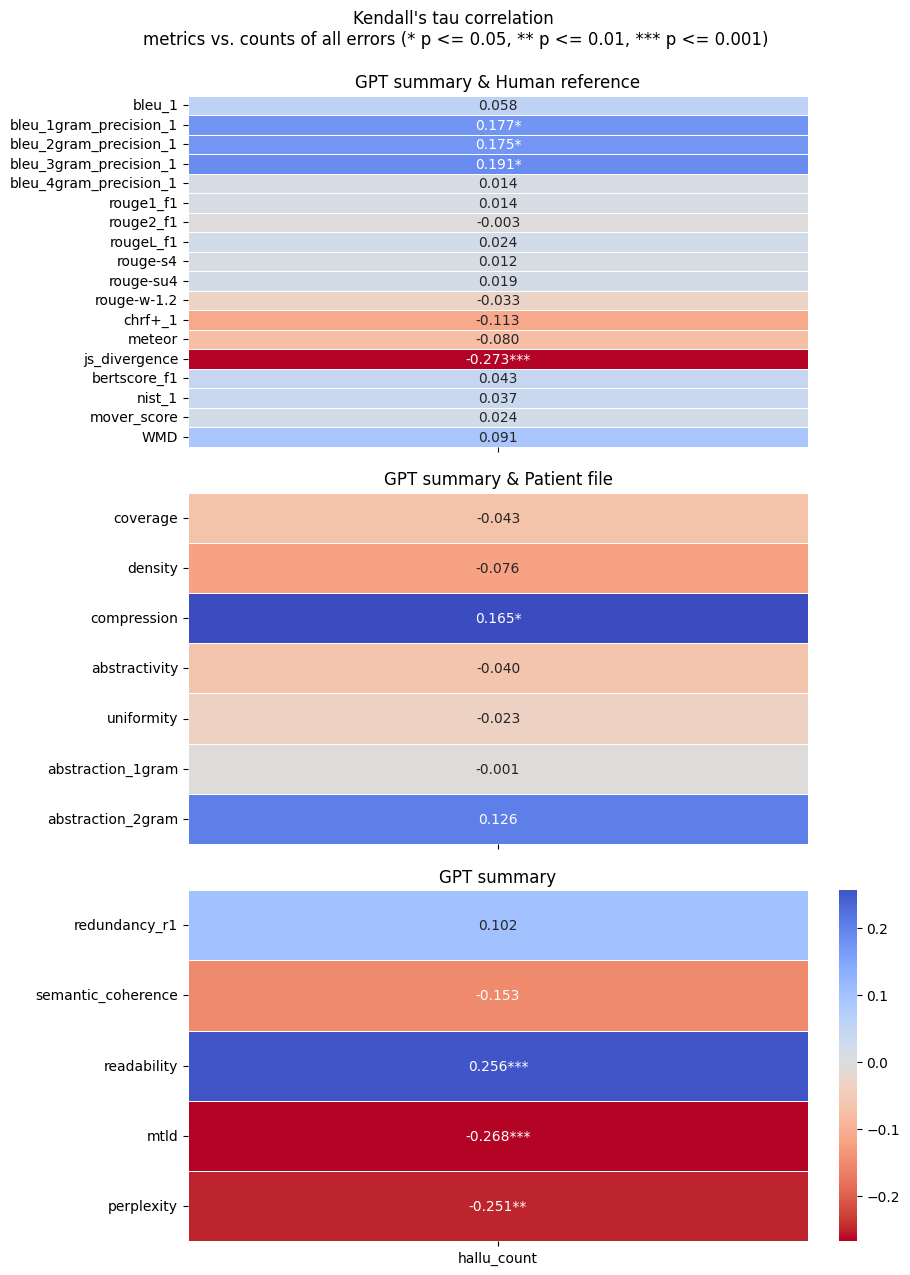

In [32]:
# FOR ALL ERRORS 
# plot by groups 
# Define groups
gen_ref = ['bleu_1', 'bleu_1gram_precision_1', 'bleu_2gram_precision_1', 'bleu_3gram_precision_1', 'bleu_4gram_precision_1',
           'rouge1_f1', 'rouge2_f1', 'rougeL_f1', 'rouge-s4', 'rouge-su4', 'rouge-w-1.2' ,'chrf+_1', 'meteor', 'js_divergence',
           'bertscore_f1', 'nist_1', 'mover_score', 'WMD']

gen_source = ['coverage', 'density', 'compression', 'abstractivity', 'uniformity', 
              'abstraction_1gram', 'abstraction_2gram']

gen_only = ['redundancy_r1','semantic_coherence', 'readability', 'mtld', 'perplexity'] #'perplexity'

groups = {"GPT summary & Human reference": gen_ref, "GPT summary & Patient file": gen_source, "GPT summary": gen_only}

# Use pivot_table to handle duplicates
kendall_heatmap_data = (
    corr_df_all[corr_df_all['method'] == "kendall's tau"]
    .pivot_table(index='metric', columns='target', values='correlation', aggfunc='mean')
)
kendall_annot_data = (
    corr_df_all[corr_df_all['method'] == "kendall's tau"]
    .pivot_table(index='metric', columns='target', values='annot', aggfunc='first')
)

kendall_annot_data = kendall_annot_data[target_columns_all]
kendall_heatmap_data = kendall_heatmap_data[target_columns_all]

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(9, 12), sharex=True, sharey=False, layout='constrained')

for ax, (group_name, metrics) in zip(axs, groups.items()):
    sns.heatmap(
        kendall_heatmap_data.loc[metrics],   # only that group’s rows
        annot=kendall_annot_data.loc[metrics],
        fmt='',
        cmap='coolwarm_r',
        center=0,
        linewidths=0.5,
        cbar=(ax == axs[-1]),   # show colorbar only on last subplot
        # cbar_kws={'label': 'Correlation coefficient'} if ax == axs[-1] else None,
        ax=ax
    )
    ax.set_title(group_name)
    ax.set_xlabel('')
    ax.set_ylabel('')


fig.suptitle("Kendall's tau correlation \nmetrics vs. counts of all errors (* p <= 0.05, ** p <= 0.01, *** p <= 0.001)", y=1.05)
fig.set_constrained_layout_pads(hspace=0.06)
plt.show()


## Spearman correlation

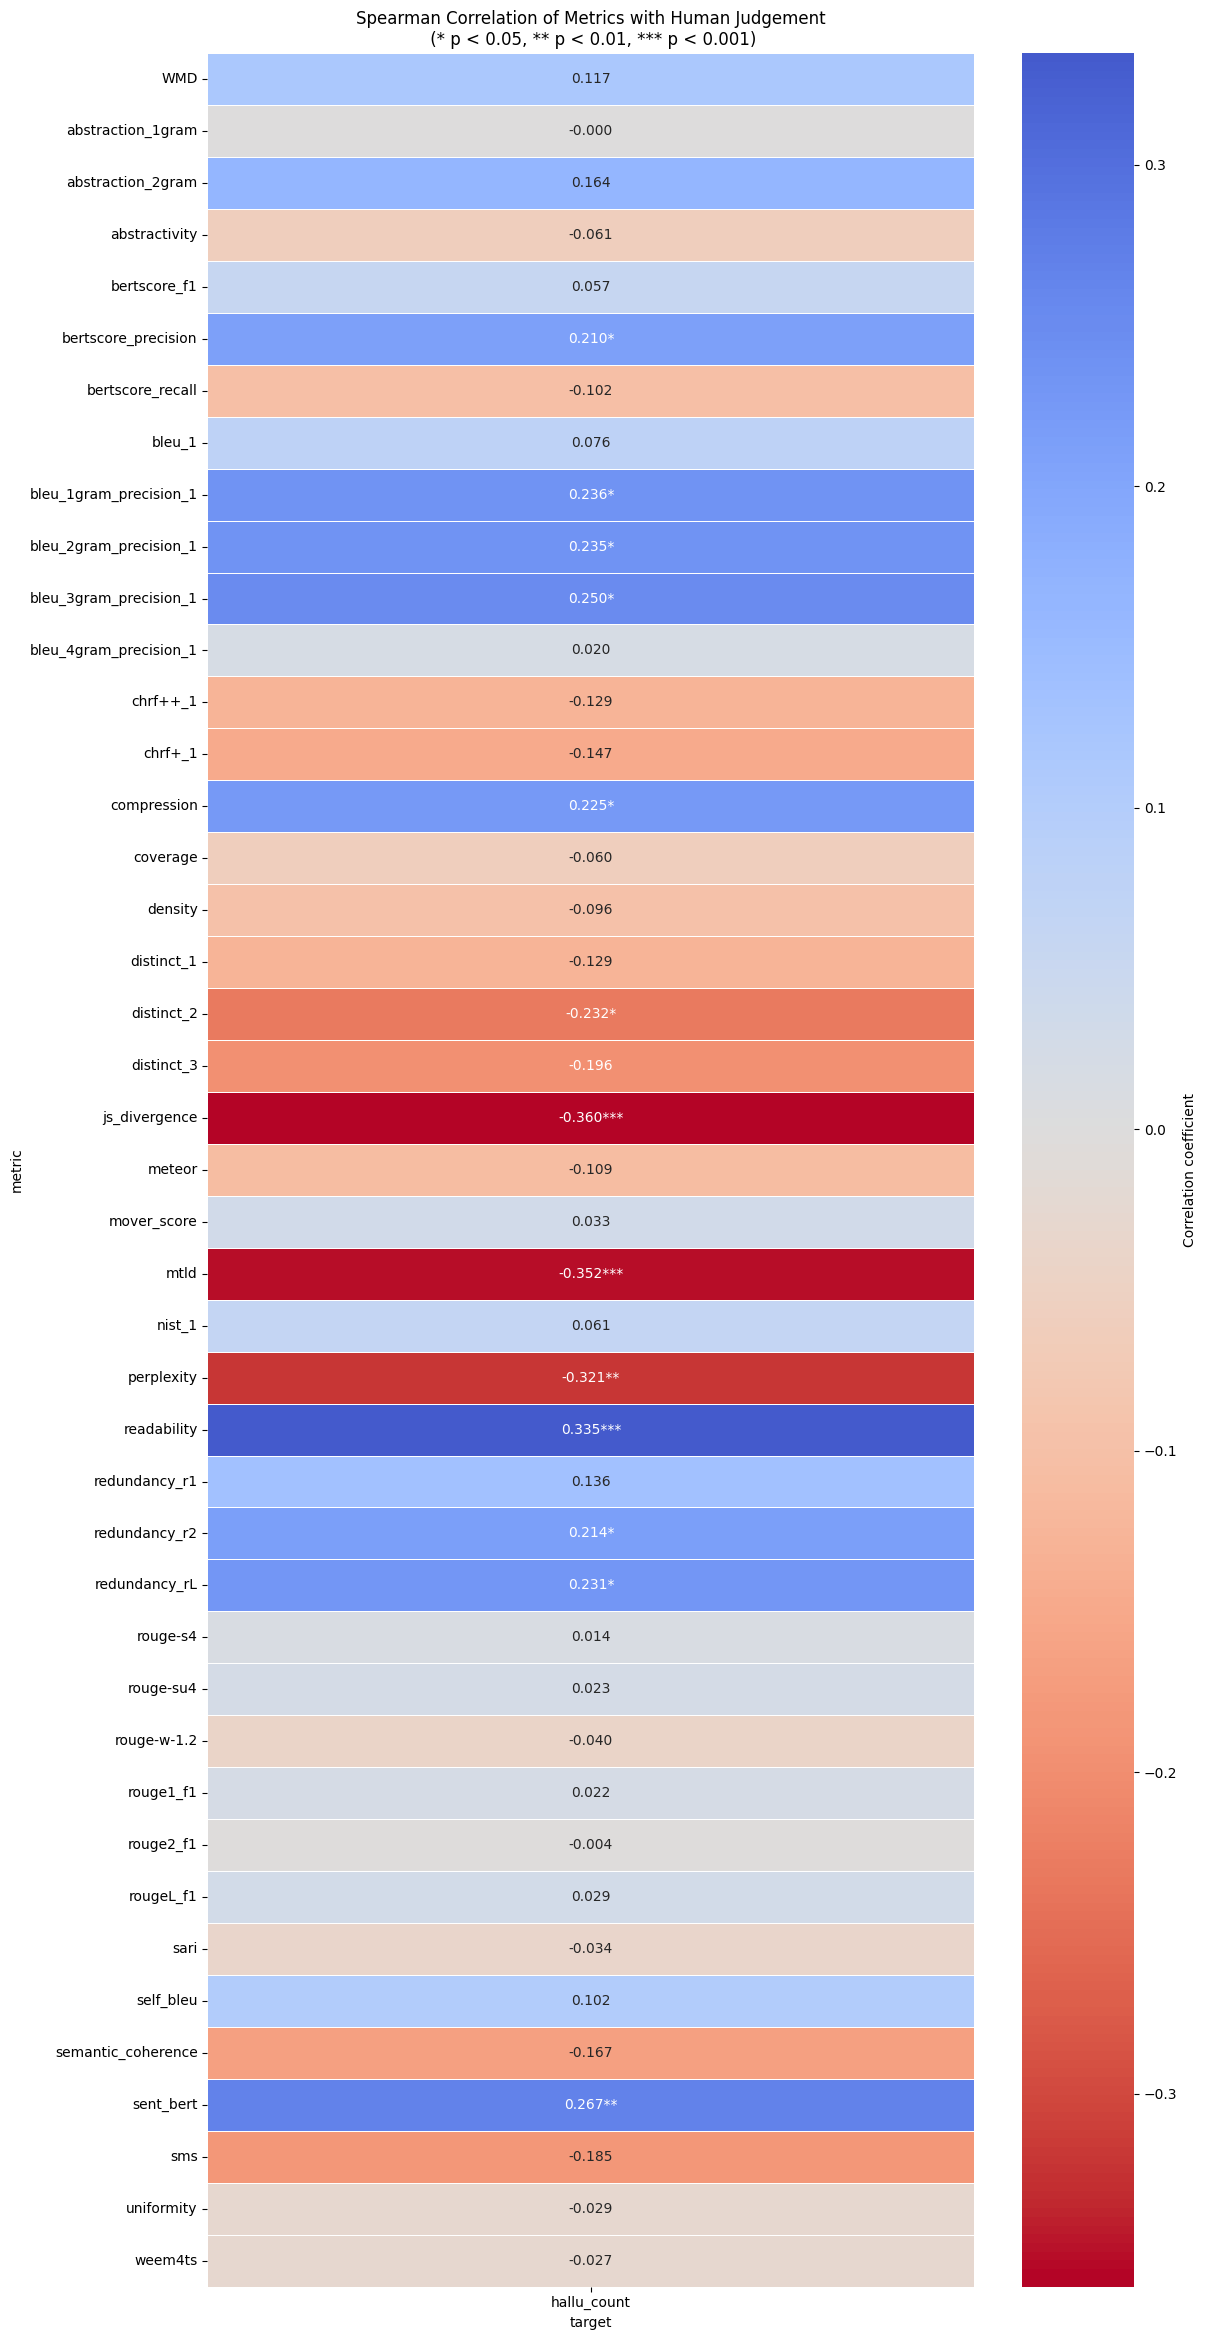

In [34]:
# spearman heatmap
spearman_heatmap_data = corr_df_all[corr_df_all['method'] == "spearman r"].pivot(index='metric', columns='target', values='correlation')
spearman_annot_data = corr_df_all[corr_df_all['method'] == "spearman r"].pivot(index='metric', columns='target', values='annot')

# Plot
plt.figure(figsize=(12, len(metric_columns) * 0.5 + 2))
sns.heatmap(
    spearman_heatmap_data,
    annot=spearman_annot_data,
    fmt='',
    cmap='coolwarm_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation coefficient'}
)
plt.title("Spearman Correlation of Metrics with Human Judgement\n (* p < 0.05, ** p < 0.01, *** p < 0.001)")
plt.tight_layout()
plt.show()

In [ ]:
# EXPORT TO EXCEL 
export_table = spearman_annot_data.astype(str)

# Export to Excel
export_table.to_excel("en_spearman_table.xlsx")

## Token counts 

In [ ]:
# count token numbers 

from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')  

def count_tokens(text):
    if pd.isna(text):
        return 0
    tokens = word_tokenize(text, language='english')
    return len(tokens)

data_df['generation_token'] = data_df['generation'].apply(count_tokens)
data_df['reference_token'] = data_df['human_reference'].apply(count_tokens)
data_df['source_token'] = data_df['patient_file'].apply(count_tokens)

#data_df.to_csv("./data/mimic-hallu-may29.csv")


In [36]:
def format_stats(col):
    return (
        f"{col.mean():.0f} "
        f"(SD {col.std():.0f}, "
        f"median {col.median():.1f}, "
        f"IQR {col.quantile(0.25):.0f}-{col.quantile(0.75):.0f})"
    )

formatted = data_df[[
    "generation_token",
    "reference_token",
    "source_token"
]].apply(format_stats)

print(formatted)

generation_token     149 (SD 46, median 157.0, IQR 114-180)
reference_token      153 (SD 38, median 134.0, IQR 124-180)
source_token        394 (SD 153, median 361.5, IQR 284-469)
dtype: object


## Correlation between hallucination and token count

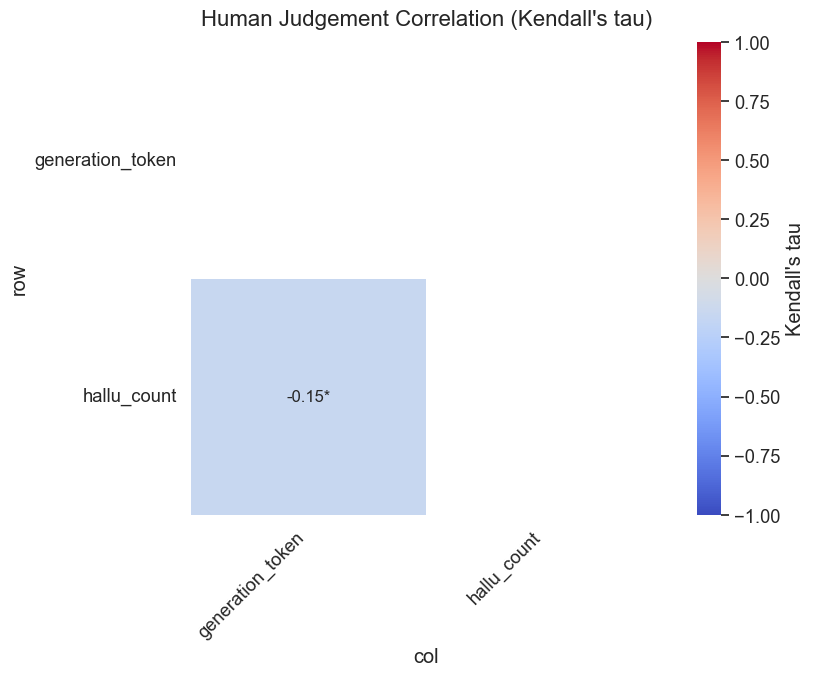

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# Define your correlation function
def compute_corr(method_func, x, y):
    corr, p = method_func(x, y)
    return corr, p

# Define target columns
target_columns = [
'hallu_count', 'generation_token'
]

subset = data_df[target_columns].dropna()

results = {
    'row': [],
    'col': [],
    'method': [],
    'correlation': [],
    'p_value': [],
    'annot': []
}

# Compute correlations for all pairs (including diagonal)
for col1 in target_columns:
    for col2 in target_columns:
        for method_name, method_func in {
            "pearson r": pearsonr,
            "spearman r": spearmanr,
            "kendall's tau": kendalltau
        }.items():
            x = subset[col1]
            y = subset[col2]
            corr, p = compute_corr(method_func, x, y)
            results['row'].append(col1)
            results['col'].append(col2)
            results['method'].append(method_name)
            results['correlation'].append(corr)
            results['p_value'].append(p)
            if p <= 0.001:
                star = '***'
            elif p <= 0.01:
                star = '**'
            elif p <= 0.05:
                star = '*'
            else:
                star = ''
            results['annot'].append(f"{corr:.2f}{star}")

# Create DataFrame
human_corr_df = pd.DataFrame(results)


kendall_df = human_corr_df[human_corr_df['method'] == "kendall's tau"]

# Pivot to wide format
corr_matrix = kendall_df.pivot(index='row', columns='col', values='correlation')
annot_matrix = kendall_df.pivot(index='row', columns='col', values='annot')

# Mask upper triangle and diagonal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set plot style
sns.set(style="white", font_scale=1.2)
plt.figure(figsize=(9, 7))

# Draw heatmap
ax = sns.heatmap(
    corr_matrix,
    annot=annot_matrix,
    mask=mask,
    fmt='',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': "Kendall's tau"},
    linewidths=0.7,
    square=True,
    annot_kws={"size": 12}
)

# Aesthetic settings
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Human Judgement Correlation (Kendall's tau)", fontsize=16, pad=12)
plt.tight_layout()
plt.show()


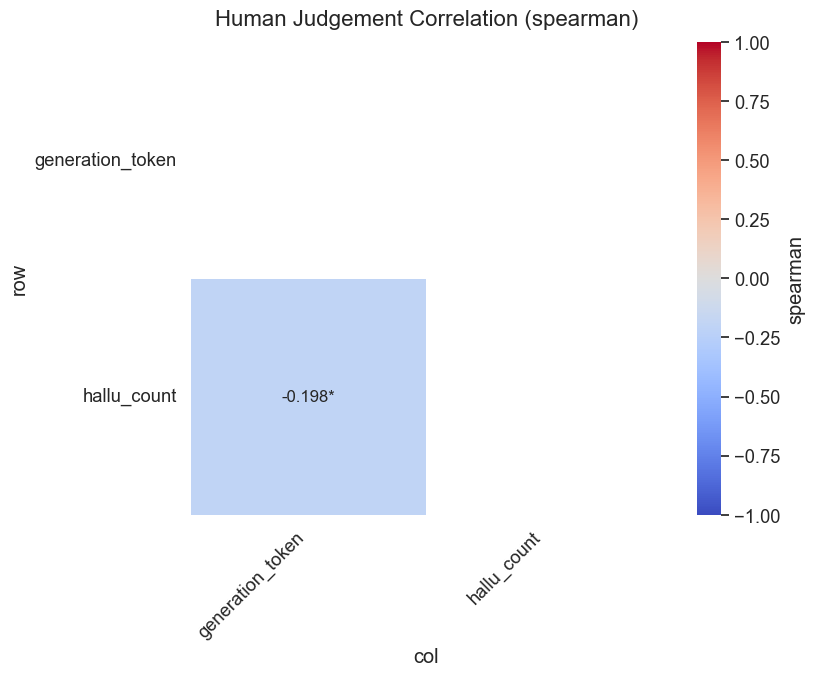

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# Define your correlation function
def compute_corr(method_func, x, y):
    corr, p = method_func(x, y)
    return corr, p

# Define target columns
target_columns = [
'hallu_count', 'generation_token'
]

subset = data_df[target_columns].dropna()

results = {
    'row': [],
    'col': [],
    'method': [],
    'correlation': [],
    'p_value': [],
    'annot': []
}

# Compute correlations for all pairs (including diagonal)
for col1 in target_columns:
    for col2 in target_columns:
        for method_name, method_func in {
            "pearson r": pearsonr,
            "spearman r": spearmanr,
            "kendall's tau": kendalltau
        }.items():
            x = subset[col1]
            y = subset[col2]
            corr, p = compute_corr(method_func, x, y)
            results['row'].append(col1)
            results['col'].append(col2)
            results['method'].append(method_name)
            results['correlation'].append(corr)
            results['p_value'].append(p)
            if p <= 0.001:
                star = '***'
            elif p <= 0.01:
                star = '**'
            elif p <= 0.05:
                star = '*'
            else:
                star = ''
            results['annot'].append(f"{corr:.3f}{star}")

# Create DataFrame
human_corr_df = pd.DataFrame(results)


spearman_df = human_corr_df[human_corr_df['method'] == "spearman r"]

# Pivot to wide format
corr_matrix = spearman_df.pivot(index='row', columns='col', values='correlation')
annot_matrix = spearman_df.pivot(index='row', columns='col', values='annot')

# Mask upper triangle and diagonal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set plot style
sns.set(style="white", font_scale=1.2)
plt.figure(figsize=(9, 7))

# Draw heatmap
ax = sns.heatmap(
    corr_matrix,
    annot=annot_matrix,
    mask=mask,
    fmt='',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': "spearman"},
    linewidths=0.7,
    square=True,
    annot_kws={"size": 12}
)

# Aesthetic settings
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Human Judgement Correlation (spearman)", fontsize=16, pad=12)
plt.tight_layout()
plt.show()


### boxplot

In [39]:
df_all = pd.concat([metric_df, data_df], axis=1)
pairs = {
    "hallu_count": ["js_divergence", "mtld", "readability"],

}
import numpy as np
import pandas as pd

plot_df = []

for error_col, metrics in pairs.items():
    for metric in metrics:

        tmp = df_all[[error_col, metric]].copy()

        tmp["error_group"] = np.where(tmp[error_col] == 0, "No error", "Error present")
        tmp["error_type"] = error_col
        tmp["metric"] = metric
        tmp["value"] = tmp[metric]

        plot_df.append(tmp[["error_type", "metric", "error_group", "value"]])

plot_df = pd.concat(plot_df, ignore_index=True)

error_labels = {
    "hallu_count": "Hallucinations (MIMIC)",

}



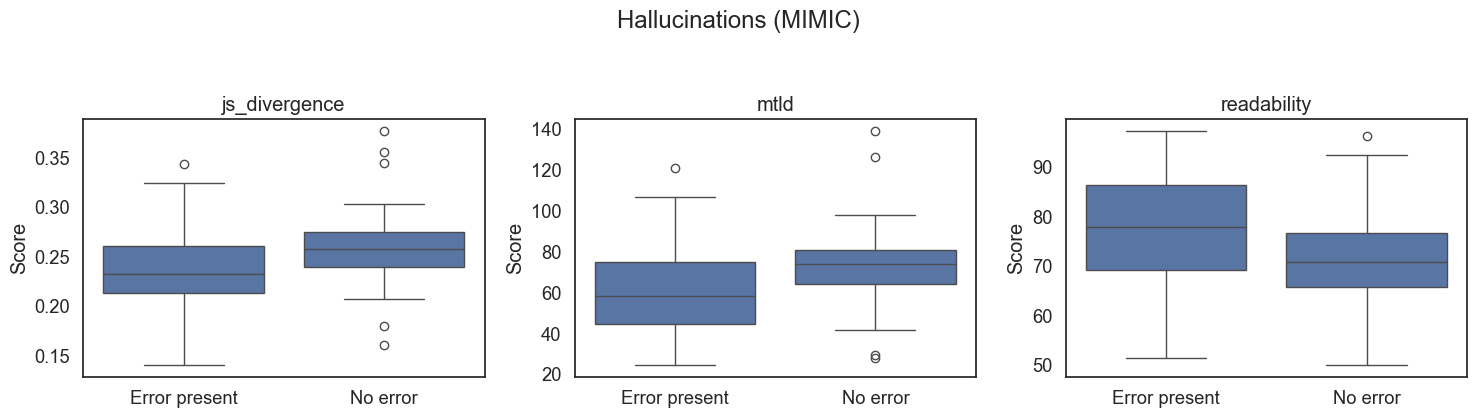

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

for error_col, metrics in pairs.items():

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4), sharey=False)

    if len(metrics) == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):

        tmp = df_all[[error_col, metric]].copy()
        tmp["error_group"] = np.where(tmp[error_col] == 0, "No error", "Error present")
        tmp = tmp.dropna()

        sns.boxplot(
            data=tmp,
            x="error_group",
            y=metric,
            ax=axes[i]
        )

        axes[i].set_title(metric)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Score")

    fig.suptitle(error_labels.get(error_col, error_col), y=1.05)
    plt.tight_layout()
    plt.show()

In [41]:
(plot_df[plot_df['metric'] == 'js_divergence']['value'] == df_all['js_divergence']).all()

True

In [43]:


from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

GROUP_A = 'No error'
GROUP_B = 'Error present'
ALPHA = 0.05

results = []

def fmt_p(p):
    if p < 0.001:
        return f'{p:.2e}'   # → 1.59e-07
    return f'{p:.3f}'       # → 0.034

for error_type in plot_df['error_type'].unique():
    for metric in plot_df['metric'].unique():
        sub = plot_df[(plot_df['error_type'] == error_type) & (plot_df['metric'] == metric)]
        a = sub[sub['error_group'] == GROUP_A]['value'].values
        b = sub[sub['error_group'] == GROUP_B]['value'].values

        if len(a) < 3 or len(b) < 3:
            continue  # skip if too few observations

        stat, p = mannwhitneyu(a, b, alternative='two-sided')

        results.append({
            'error_type': error_type,
            'metric': metric,
            'U_statistic': stat,
            'p_value': p,
            'size_no_error': len(a), 
            'size_error': len(b),
            'median_no_error': pd.Series(a).median().round(2),
            'median_error': pd.Series(b).median().round(2),
            'direction': '↑ no error' if pd.Series(a).median().round(3) > pd.Series(b).median().round(3) else '↓ no error'
        })

claude_results_df = pd.DataFrame(results)

# FDR correction across all tests together
reject, p_fdr, _, _ = multipletests(claude_results_df['p_value'], method='fdr_bh', alpha=ALPHA)
claude_results_df['p_fdr'] = p_fdr
claude_results_df['significant'] = reject

claude_results_df['p_fdr_display'] = claude_results_df['p_fdr'].apply(fmt_p)


print(claude_results_df.to_string(index=False))

 error_type        metric  U_statistic  p_value  size_no_error  size_error  median_no_error  median_error  direction    p_fdr  significant p_fdr_display
hallu_count js_divergence       1720.0 0.001209             50          50             0.26          0.23 ↑ no error 0.001814         True         0.002
hallu_count          mtld       1720.0 0.001209             50          50            74.07         58.38 ↑ no error 0.001814         True         0.002
hallu_count   readability        875.0 0.009830             50          50            70.65         77.74 ↓ no error 0.009830         True         0.010


In [ ]:
claude_results_df.to_excel("./correlation table/mimic-mann-whitney.xlsx", index=False)

In [44]:
from scipy.stats import rankdata
# Do the two metrics produce the same rank order?
sub = plot_df[plot_df['error_type'] == 'hallu_count']
jsd = sub[sub['metric']=='js_divergence']['value'].values
mtld = sub[sub['metric']=='mtld']['value'].values

import numpy as np
print(np.corrcoef(rankdata(jsd), rankdata(mtld)))

[[1.       0.420042]
 [0.420042 1.      ]]
